# Data Cleaning - VNExpress News Dataset

Dataset được crawl từ hai chuyên mục:

- Sức khỏe
- Giải trí

Notebook này thực hiện:

1. Kiểm tra dữ liệu thô
2. Làm sạch dữ liệu
3. Chuẩn hóa định dạng
4. Tạo feature mới
5. Xuất dataset sạch để phân tích tiếp

## 1. Import thư viện

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

## 2. Đọc dữ liệu thô

In [98]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1181, 11)


,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,Các yếu tố âm thầm gây hại phổi ngoài thuốc lá,"Không chỉ thuốc lá, môi trường làm việc thường...","Thứ sáu, 27/2/2026, 18:00 (GMT+7)",Hút thuốc lá không phải là thủ phạm duy nhất g...,https://i1-suckhoe.vnecdn.net/2026/02/27/1428b...,Lê Nguyễn,"hô hấp, tổn thương phổi",Sức khỏe,Các bệnh,0,https://vnexpress.net/cac-yeu-to-am-tham-gay-h...
1,Đội trưởng Tạ phim 'Mưa đỏ' đóng MV của Đàm Vĩ...,"Phương Nam - đội trưởng Tạ phim ""Mưa đỏ"" - cùn...","Chủ nhật, 8/2/2026, 10:10 (GMT+7)","Phương Nam, Lâm Thanh Nhã hóa thân thành những...",https://i1-giaitri.vnecdn.net/2026/02/02/phuon...,Hoàng Dung,"đàm vĩnh hưng, phương nam, lâm thanh nhã, mưa đỏ",Giải trí,Nhạc,0,https://vnexpress.net/doi-truong-ta-phim-mua-d...
2,Phẫu thuật Whipple là gì?,"Tôi có khối u ở đầu tuyến tụy, bác sĩ tư vấn p...","Thứ ba, 3/3/2026, 12:00 (GMT+7)",Trả lời:\nPhẫu thuật Whipple là kỹ thuật cắt b...,https://i1-suckhoe.vnecdn.net/2026/03/03/pic-1...,ThS.BS Đào Văn Minh,"u tá tụy, mổ nội soi",Sức khỏe,Các bệnh,0,https://vnexpress.net/phau-thuat-whipple-la-gi...
3,Nhà văn Nguyễn Ngọc Tiến: 'Tết Nguyên đán giá ...,Ông Nguyễn Ngọc Tiến - tác giả nhiều khảo cứu ...,"Thứ tư, 18/2/2026, 05:00 (GMT+7)",Nhà văn Nguyễn Ngọc Tiến sinh ra và lớn lên ở ...,https://i1-giaitri.vnecdn.net/2026/02/17/nguye...,Phương Linh,"nhà văn nguyễn ngọc tiến, tết hà nội",Giải trí,Sách,0,https://vnexpress.net/nha-van-nguyen-ngoc-tien...
4,Bé 3 ngày tuổi được phẫu thuật cắt u vùng cùng...,"TP HCMBé gái chào đời nặng 3,7 kg với khối u g...","Thứ sáu, 27/2/2026, 13:00 (GMT+7)","Ngay từ trong bụng mẹ, bé được siêu âm tháng t...",https://i1-suckhoe.vnecdn.net/2026/02/27/image...,Giản Đơn,"tp hcm, khối u, trẻ sơ sinh, phẫu thuật khối u",Sức khỏe,Các bệnh,0,https://vnexpress.net/be-3-ngay-tuoi-duoc-phau...


## 3. Thông tin dữ liệu

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1181 non-null   str  
 1   description       1181 non-null   str  
 2   date              1181 non-null   str  
 3   content           1181 non-null   str  
 4   thumbnail         1181 non-null   str  
 5   author            1181 non-null   str  
 6   tags              1176 non-null   str  
 7   group             1181 non-null   str  
 8   category          1181 non-null   str  
 9   nums_of_comments  1181 non-null   int64
 10  url               1181 non-null   str  
dtypes: int64(1), str(10)
memory usage: 101.6 KB


## 4. Kiểm tra dữ liệu thiếu

In [100]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
tags,5,0.42337
title,0,0.00000
description,0,0.00000
date,0,0.00000
content,0,0.00000
thumbnail,0,0.00000
author,0,0.00000
group,0,0.00000
category,0,0.00000
nums_of_comments,0,0.00000


## 5. Xử lý dữ liệu thời gian bị thiếu

## 5. Phân bố dữ liệu ban đầu

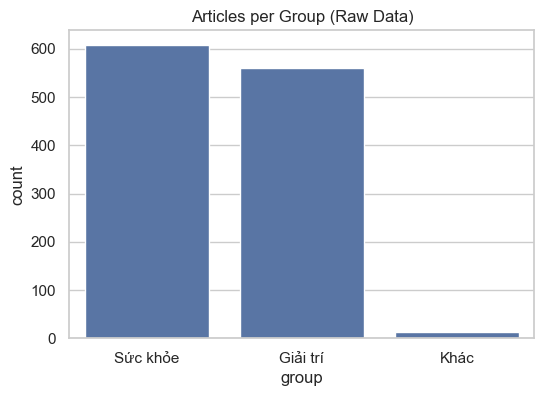

In [101]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="group")

plt.title("Articles per Group (Raw Data)")
plt.show()

# 6. Loại bỏ dữ liệu trùng lặp

In [102]:
print("Rows before:", len(df))

df = df.drop_duplicates(subset="url")

print("Rows after:", len(df))

Rows before: 1181
Rows after: 1181


## 7. Loại bỏ bài viết thiếu nội dung

In [103]:
df = df.dropna(subset=["title", "content"])

print("Rows after removing missing:", len(df))

Rows after removing missing: 1181


# 8. Làm sạch dữ liệu văn bản

In [104]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [105]:
df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

## 9. Phân tích độ dài văn bản

In [106]:
df["title_length"] = df["title"].apply(lambda x: len(x.split()))
df["content_length"] = df["content"].apply(lambda x: len(x.split()))

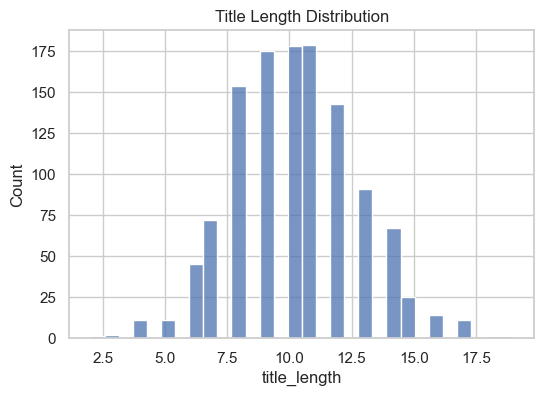

In [107]:
plt.figure(figsize=(6,4))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

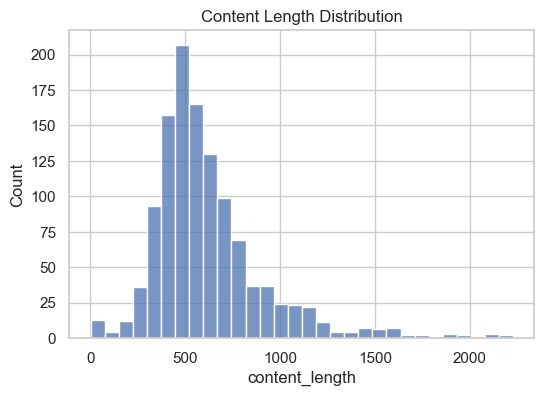

In [108]:
plt.figure(figsize=(6,4))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

# 10. Chuẩn hóa định dạng ngày

In [109]:
def clean_date(text):

    if pd.isna(text):
        return text

    text = re.sub(r'^Thứ.*?,\s*', '', text)

    text = re.sub(r'\(.*?\)', '', text)

    return text.strip()

In [110]:
df["date"] = df["date"].apply(clean_date)

In [111]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y, %H:%M",
    errors="coerce"
)

## 11. Chuẩn hóa group/category

In [112]:


def normalize_category(row):
    group = row["group"]
    category = row["category"]

    # Trường hợp crawler lấy được: Các bệnh > Hô hấp

    # Nếu muốn làm theo hướng gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    # if group == "Các bệnh":
    #     group = "Sức khỏe"
    #     category = "Các bệnh"

    # Nếu muốn giữ nguyên các nhóm riêng biệt, nhưng vẫn gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    if group == "Các bệnh":
        group = "Sức khỏe"

    return pd.Series([group, category])


df[["group", "category"]] = df.apply(normalize_category, axis=1)

# print("Unique groups:", df["group"].unique())
# print("Unique categories:", df["category"].unique())

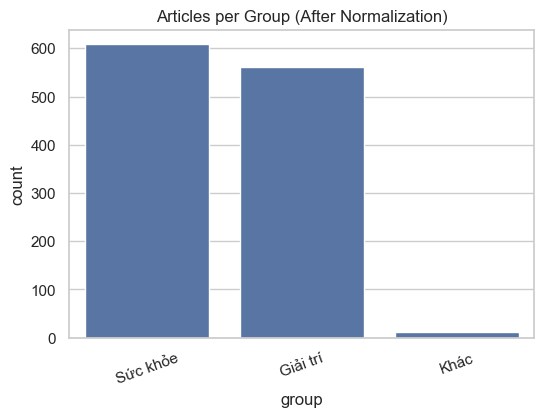

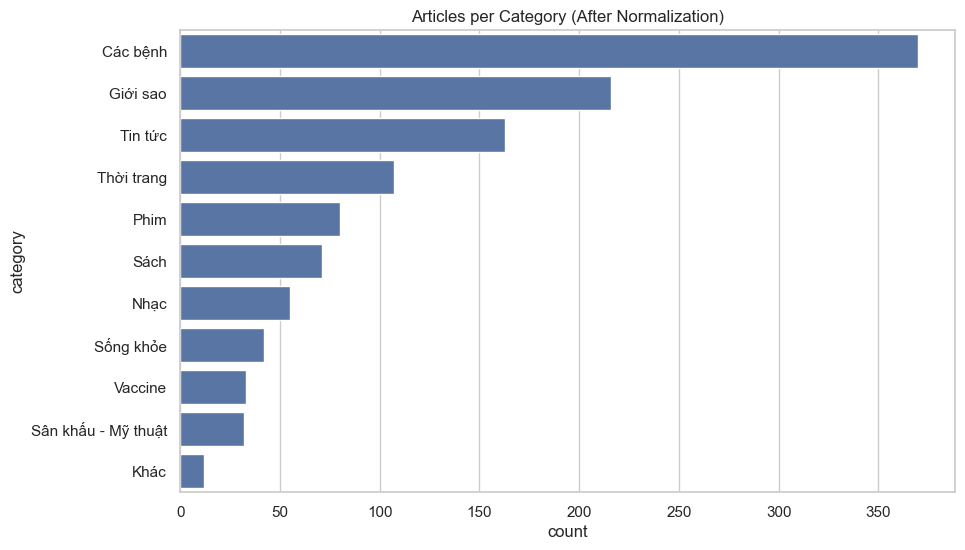

In [113]:
# Visualize group distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="group")
plt.title("Articles per Group (After Normalization)")
plt.xticks(rotation=20)
plt.show()


# Visualize category distribution

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
plt.title("Articles per Category (After Normalization)")

plt.show()

## 12. Tạo feature thời gian

In [114]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

# Điền giá trị null
df = df.fillna({
    "date": pd.to_datetime("2026-01-01 07:00:00"),
    "year": 2026.0,
    "month": 1.0,
    "hour": 7.0,
    "description": "",
    "thumbnail": "No Image",
    "tags": "Notag",
    'author': 'Không xác định',
})

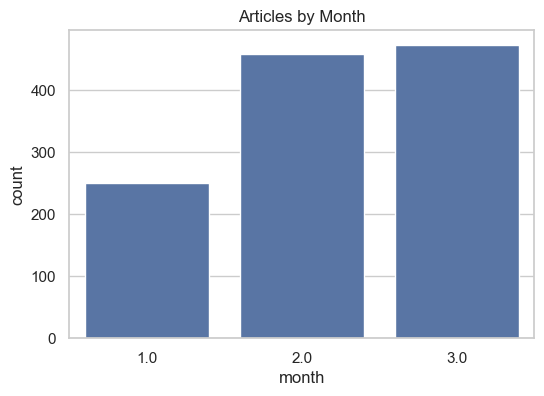

In [115]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="month")

plt.title("Articles by Month")

plt.show()

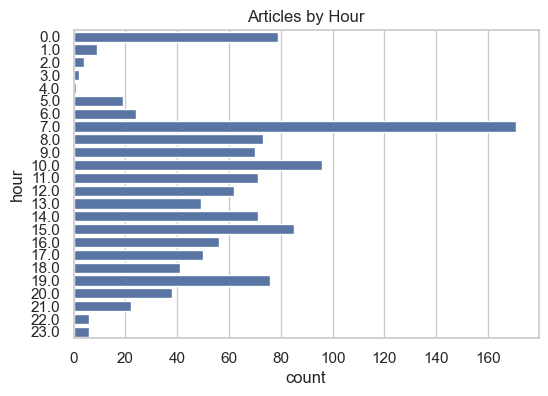

In [116]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, y="hour")

plt.title("Articles by Hour")

plt.show()

## 13. Phân tích số lượng bình luận

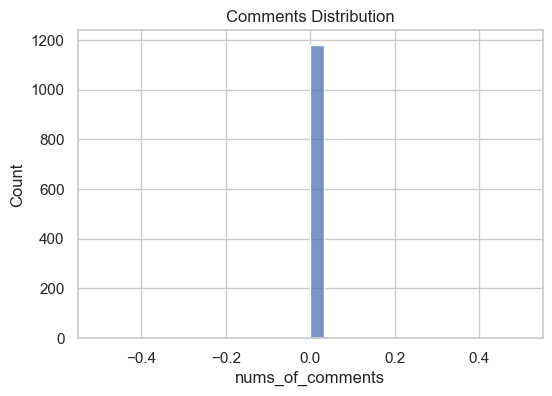

In [117]:
plt.figure(figsize=(6,4))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Comments Distribution")

plt.show()

## 14. Kiểm tra dataset sau khi clean

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             1181 non-null   str           
 1   description       1181 non-null   str           
 2   date              1181 non-null   datetime64[us]
 3   content           1181 non-null   str           
 4   thumbnail         1181 non-null   str           
 5   author            1181 non-null   str           
 6   tags              1181 non-null   str           
 7   group             1181 non-null   str           
 8   category          1181 non-null   str           
 9   nums_of_comments  1181 non-null   int64         
 10  url               1181 non-null   str           
 11  title_length      1181 non-null   int64         
 12  content_length    1181 non-null   int64         
 13  year              1181 non-null   float64       
 14  month             1181 non-null   f

In [119]:
df.describe()

,date,nums_of_comments,title_length,content_length,year,month,hour
count,1181,1181.0,1181.000000,1181.000000,1181.0,1181.000000,1181.000000
mean,2026-02-18 05:25:37.798475,0.0,10.243014,616.392041,2026.0,2.188823,11.420830
min,2026-01-01 07:00:00,0.0,2.000000,2.000000,2026.0,1.000000,0.000000
25%,2026-02-05 15:55:00,0.0,8.000000,441.000000,2026.0,2.000000,7.000000
50%,2026-02-26 06:00:00,0.0,10.000000,550.000000,2026.0,2.000000,11.000000
75%,2026-03-06 06:00:00,0.0,12.000000,724.000000,2026.0,3.000000,15.000000
max,2026-03-13 19:00:00,0.0,19.000000,2228.000000,2026.0,3.000000,23.000000
std,NaN,0.0,2.500382,295.985804,0.0,0.759623,5.446337


## 15. Lưu dataset đã clean

In [120]:
df.to_csv("../data/vnexpress_clean_data.csv", index=False)

print("Saved clean dataset")

Saved clean dataset
